# Darcy Flow 

Linear version.

$$
\begin{equation}
- \nabla \cdot (a(x) \nabla u(x)) = f(x) \quad \text{in $\Omega$}  
\end{equation} 
$$

$$
\begin{equation}
u(x) = h(x) \quad \text{in $\partial\Omega$}  
\end{equation} 
$$

To begin with, we start by assuming $f=1$ and $a_{\beta} \coloneqq e^{-x} sin(\beta y)$.

$$
\partial_x a = -a~;~\partial_y a = \beta e^{-x} cos(\beta y).
$$

Good reference for the Darcy Finite differences Solver: https://github.com/PKU-CMEGroup/InverseProblems.jl/blob/724e1076e633208195dcac41aafd2d5587840ff4/Fluid/Darcy-2D-Adjoint.ipynb
https://github.com/PKU-CMEGroup/InverseProblems.jl/blob/724e1076e633208195dcac41aafd2d5587840ff4/Posterior/Darcy-1D.ipynb



In [ ]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

## Aim
To solve the 2D Darcy flow equation with a spatially varying coefficient $a(x, y)$, we use a **Finite Difference Method (FDM)** on a structured grid. 

### The Mathematical Setup
The equation is given by:
$$-\nabla \cdot (a(x,y) \nabla u(x,y)) = f(x,y)$$

Expanding this using the product rule in 2D:
$$-\left[ \frac{\partial}{\partial x} \left( a \frac{\partial u}{\partial x} \right) + \frac{\partial}{\partial y} \left( a \frac{\partial u}{\partial y} \right) \right] = f(x,y)$$

On a discrete grid, we use central differences. To maintain second-order accuracy and handle the variable coefficient $a(x,y)$ robustly, we evaluate $a$ at the "half-grid" points (staggered locations):
$$\frac{\partial}{\partial x} \left( a \frac{\partial u}{\partial x} \right) \approx \frac{a_{i+1/2, j} \frac{u_{i+1, j} - u_{i, j}}{\Delta x} - a_{i-1/2, j} \frac{u_{i, j} - u_{i-1, j}}{\Delta x}}{\Delta x}$$

### Python Implementation
We will use `scipy.sparse` to build the system matrix efficiently, as the resulting linear system $Au = b$ is very sparse.

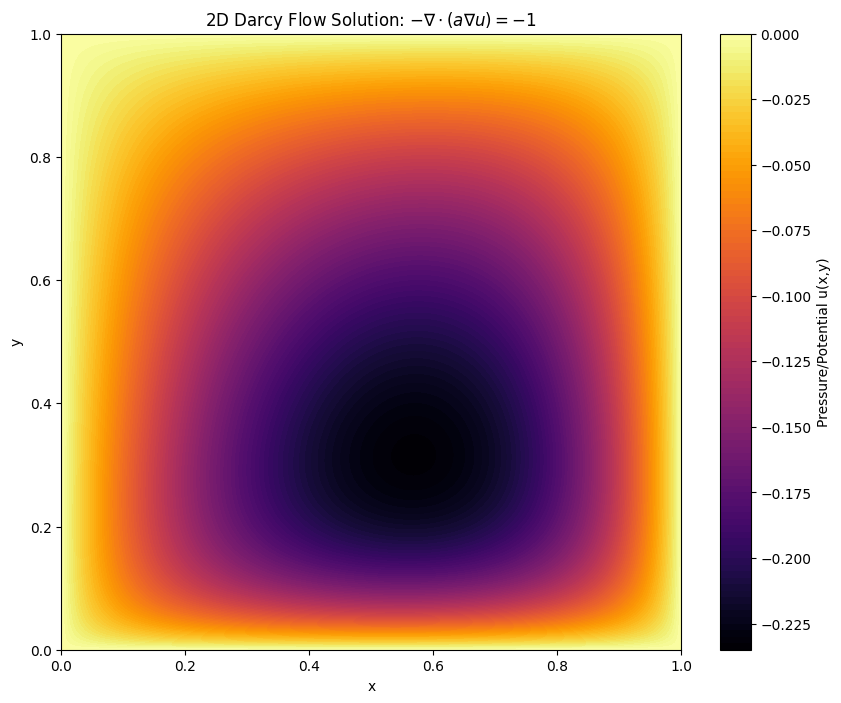

In [ ]:
# Finite differences based Darcy flow solver
def solve_darcy_2d(N=50):
    """
    Solves -div(a*grad(u)) = f on [0,1]^2 with u=0 on boundaries.
    a(x,y) = e^(-x)*sin(y)
    f(x,y) = -1
    """
    # 1. Setup Grid
    L = 1.0
    h = L / (N - 1)
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    # Total number of points
    num_pts = N * N
    
    # 2. Define functions
    def get_a(x, y):
        # We add a small epsilon (=0.1) to avoid division by zero or singular behavior 
        # since sin(0)=0 makes the equation degenerate on the boundary.

        return np.exp(-x)*np.sin(y) + 0.1  
        
        #====================================
        # OTHER POSSIBLE FUNCTIONS, a(x,y), WE TESTED FOR
        #====================================
        # return np.exp(np.sin(x)*np.cos(y))
        # return np.exp(-10*np.sin(x))
        # return np.exp(-10*np.cos(y))
    
    def get_f(x, y):
        return -1.0 * np.ones_like(x)

    # 3. Build the Sparse System Matrix (A) and Right-Hand Side (b)
    # We use lil_matrix for efficient construction, then convert to csr
    A = lil_matrix((num_pts, num_pts))
    b = np.zeros(num_pts)
    
    # Flattening helper: (i, j) -> index
    def idx(i, j):
        return i * N + j

    for i in range(N):
        for j in range(N):
            row = idx(i, j)
            
            # Apply Dirichlet Boundary Conditions (u=0)
            if i == 0 or i == N-1 or j == 0 or j == N-1:
                A[row, row] = 1.0
                b[row] = 0.0
            else:
                # Midpoint coordinates for coefficient 'a'
                xw = x[i] - 0.5*h # West
                xe = x[i] + 0.5*h # East
                ys = y[j] - 0.5*h # South
                yn = y[j] + 0.5*h # North
                
                # Coefficients sampled at staggered grid points
                aw = get_a(xw, y[j])
                ae = get_a(xe, y[j])
                as_ = get_a(x[i], ys)
                an = get_a(x[i], yn)
                
                # Finite Difference discretization (Center, West, East, South, North)
                # Formula: -[ (ae(u_e - u_c)/h - aw(u_c - u_w)/h)/h + ... ] = f
                A[row, idx(i, j)]   = (ae + aw + an + as_) / h**2
                A[row, idx(i+1, j)] = -ae / h**2
                A[row, idx(i-1, j)] = -aw / h**2
                A[row, idx(i, j+1)] = -an / h**2
                A[row, idx(i, j-1)] = -as_ / h**2
                
                b[row] = get_f(x[i], y[j])

    # 4. Solve the Linear System
    A_csr = A.tocsr()
    u_flat = spsolve(A_csr, b)
    u = u_flat.reshape((N, N))
    
    return X, Y, u

# Execute Solver
N_res = 400
X, Y, U = solve_darcy_2d(N_res)

# 5. Visualization
plt.figure(figsize=(10, 8))
cont = plt.contourf(X, Y, U, cmap='inferno', levels=100)
plt.colorbar(cont, label='Pressure/Potential u(x,y)')
plt.title(r'2D Darcy Flow Solution: $-\nabla \cdot (a \nabla u) = -1$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

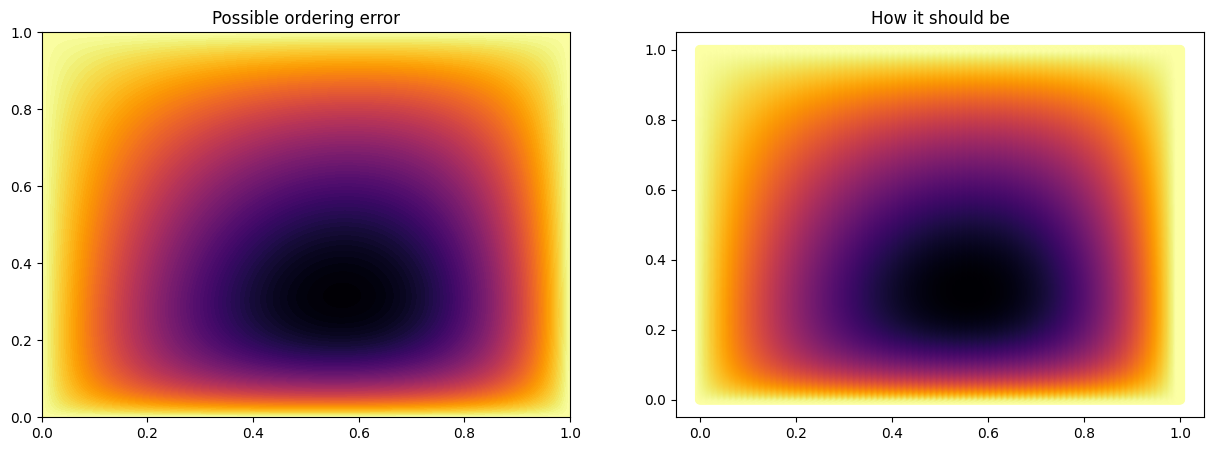

In [14]:
# Sanity check for solutions: The ordering sometimes can be messed up because of np.meshgrid (use indexing='ij') - Check if the 'scatter plot' shape corresponds to the contourf shape.  
fig, axs = plt.subplots(1,2, figsize=(15,5))
axs[0].contourf(X, Y, U, cmap='inferno', levels=100)
axs[0].set_title('Possible ordering error')
axs[1].scatter(X.flatten(), Y.flatten(), c=U.flatten(), cmap='inferno') 
axs[1].set_title('How it should be')
plt.show()

In [15]:
# Saving the solution
np.savetxt('DarcySoln.txt', U)